In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from csv import reader
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [14]:
df = pd.read_csv("../data_raw/market_basket_analysis.csv", delimiter=';')

df.head()

/var/folders/xn/75cqdkzs2tlbx5cnr6s28pdw0000gn/T/ipykernel_3489/3997799180.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data_raw/market_basket_analysis.csv", delimiter=';')


,BillNo,Itemname,Quantity,Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01.12.2010 08:26,"2,55",17850.0,United Kingdom
1,536365,WHITE METAL LANTERN,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01.12.2010 08:26,"2,75",17850.0,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01.12.2010 08:26,"3,39",17850.0,United Kingdom


In [15]:
print(df.shape)
print(df.columns)

df.info()
df.isna().sum()

(522064, 7)
Index(['BillNo', 'Itemname', 'Quantity', 'Date', 'Price', 'CustomerID',
       'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   BillNo      522064 non-null  object 
 1   Itemname    520609 non-null  object 
 2   Quantity    522064 non-null  int64  
 3   Date        522064 non-null  object 
 4   Price       522064 non-null  object 
 5   CustomerID  388023 non-null  float64
 6   Country     522064 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 27.9+ MB


BillNo             0
Itemname        1455
Quantity           0
Date               0
Price              0
CustomerID    134041
Country            0
dtype: int64

In [16]:
#drop rows with missing item name
df = df.dropna(subset=["Itemname"])

if "Quantity" in df.columns:
    df = df[df["Quantity"] > 0]

df.shape

(520136, 7)

In [23]:
# Filter to Germany
df_de = df[df["Country"] == "Germany"].copy()


df_de.shape


(9042, 7)

In [27]:
item_counts = df_de["Itemname"].value_counts().head(20)
item_counts

Itemname
ROUND SNACK BOXES SET OF4 WOODLAND    113
ROUND SNACK BOXES SET OF 4 FRUITS      72
PLASTERS IN TIN WOODLAND ANIMALS       64
REGENCY CAKESTAND 3 TIER               63
WOODLAND CHARLOTTE BAG                 58
PLASTERS IN TIN CIRCUS PARADE          53
PLASTERS IN TIN SPACEBOY               49
SPACEBOY LUNCH BOX                     47
6 RIBBONS RUSTIC CHARM                 47
JUMBO BAG WOODLAND ANIMALS             46
RED TOADSTOOL LED NIGHT LIGHT          44
JAM MAKING SET PRINTED                 42
PACK OF 72 RETROSPOT CAKE CASES        39
JUMBO BAG RED RETROSPOT                36
LUNCH BAG WOODLAND                     36
STRAWBERRY LUNCH BOX WITH CUTLERY      36
GUMBALL COAT RACK                      33
SET OF 3 REGENCY CAKE TINS             32
ALARM CLOCK BAKELIKE PINK              32
RED RETROSPOT CUP                      32
Name: count, dtype: int64

In [28]:
# Remove POSTAGE since it is not a product

df_de = df_de[df_de["Itemname"].str.upper() != "POSTAGE"]

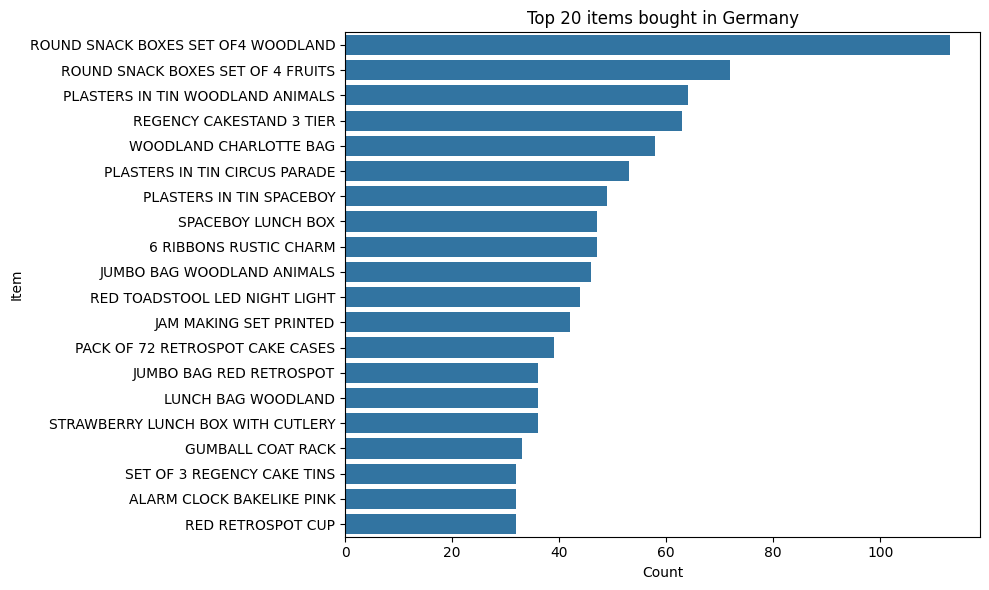

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x=item_counts.values, y=item_counts.index)
plt.xlabel("Count")
plt.ylabel("Item")
plt.title("Top 20 items bought in Germany")
plt.tight_layout()
plt.show()

In [31]:
basket = (df_de
          .groupby(["BillNo", "Itemname"])["Quantity"]
          .sum()
          .unstack()
          .fillna(0))

basket.shape

(449, 1694)

In [32]:
# Convert quantities to 1 (present) / 0 (absent)
basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)

basket_encoded.head()
basket_encoded.shape

/var/folders/xn/75cqdkzs2tlbx5cnr6s28pdw0000gn/T/ipykernel_3489/4257183616.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_encoded = basket.applymap(lambda x: 1 if x > 0 else 0)


(449, 1694)

In [33]:
item_supports = basket_encoded.mean(axis=0)

popular_items = item_supports[item_supports > 0.01].index

basket_encoded = basket_encoded[popular_items]
basket_encoded.shape

(449, 542)

In [40]:
frequent_itemsets = apriori (
    basket_encoded,
    min_support = 0.02,
    use_colnames = True
)

frequent_itemsets.sort_values("support", ascending = False).head(10)
len(frequent_itemsets)

/Users/verna/Market-Basket-Analysis/.venv/lib/python3.9/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


702

In [42]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.sort_values("lift", ascending=False).head()
len(rules)


1176

In [45]:
strong_rules = rules[
    (rules["support"] >= 0.01) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 2)
].sort_values("lift", ascending=False)

strong_rules.head(20)
#len(strong_rules)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
179,(DOLLY GIRL CHILDRENS CUP),(DOLLY GIRL CHILDRENS BOWL),0.024499,0.026726,0.024499,1.000000,37.416667,1.0,0.023844,inf,0.997717,0.916667,1.000000,0.958333
178,(DOLLY GIRL CHILDRENS BOWL),(DOLLY GIRL CHILDRENS CUP),0.026726,0.024499,0.024499,0.916667,37.416667,1.0,0.023844,11.706013,1.000000,0.916667,0.914574,0.958333
50,(PINK HAPPY BIRTHDAY BUNTING),(BLUE HAPPY BIRTHDAY BUNTING),0.020045,0.031180,0.020045,1.000000,32.071429,1.0,0.019420,inf,0.988636,0.642857,1.000000,0.821429
90,(PINK VINTAGE SPOT BEAKER),(BLUE VINTAGE SPOT BEAKER),0.024499,0.031180,0.024499,1.000000,32.071429,1.0,0.023735,inf,0.993151,0.785714,1.000000,0.892857
91,(BLUE VINTAGE SPOT BEAKER),(PINK VINTAGE SPOT BEAKER),0.031180,0.024499,0.024499,0.785714,32.071429,1.0,0.023735,4.552339,1.000000,0.785714,0.780333,0.892857
51,(BLUE HAPPY BIRTHDAY BUNTING),(PINK HAPPY BIRTHDAY BUNTING),0.031180,0.020045,0.020045,0.642857,32.071429,1.0,0.019420,2.743875,1.000000,0.642857,0.635552,0.821429
709,(RED SPOT CERAMIC DRAWER KNOB),"(BLUE SPOT CERAMIC DRAWER KNOB, WHITE SPOT RED...",0.031180,0.022272,0.020045,0.642857,28.864286,1.0,0.019350,2.737639,0.996424,0.600000,0.634722,0.771429
704,"(BLUE SPOT CERAMIC DRAWER KNOB, WHITE SPOT RED...",(RED SPOT CERAMIC DRAWER KNOB),0.022272,0.031180,0.020045,0.900000,28.864286,1.0,0.019350,9.688196,0.987345,0.600000,0.896782,0.771429
707,(BLUE SPOT CERAMIC DRAWER KNOB),"(WHITE SPOT RED CERAMIC DRAWER KNOB, RED SPOT ...",0.028953,0.026726,0.020045,0.692308,25.903846,1.0,0.019271,3.163140,0.990061,0.562500,0.683858,0.721154
706,"(WHITE SPOT RED CERAMIC DRAWER KNOB, RED SPOT ...",(BLUE SPOT CERAMIC DRAWER KNOB),0.026726,0.028953,0.020045,0.750000,25.903846,1.0,0.019271,3.884187,0.987796,0.562500,0.742546,0.721154


/var/folders/xn/75cqdkzs2tlbx5cnr6s28pdw0000gn/T/ipykernel_3489/2545828106.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


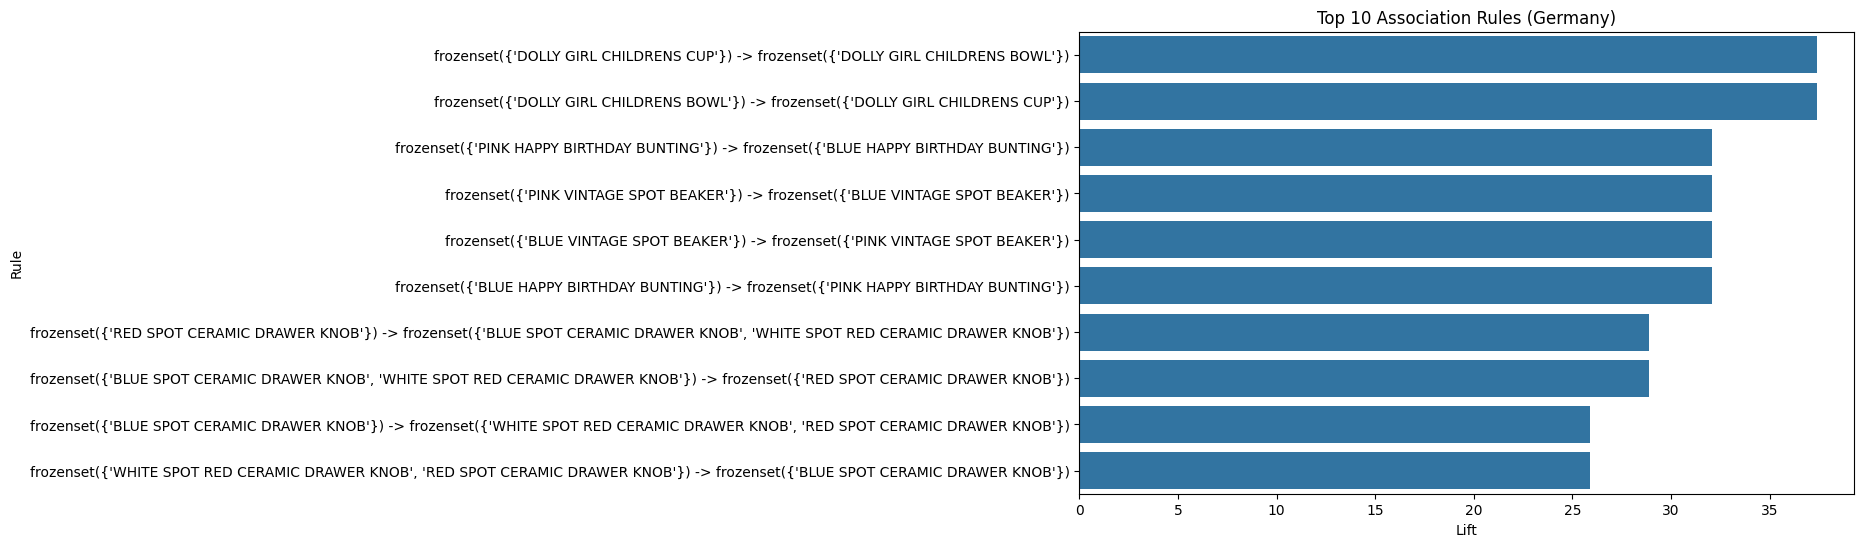

In [46]:
top_rules = strong_rules.head(10).copy()
top_rules["rule"] = top_rules["antecedents"].astype(str) + " -> " + top_rules["consequents"].astype(str)

plt.figure(figsize=(10,6))
sns.barplot(x="lift", y="rule", data=top_rules)
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.title("Top 10 Association Rules (Germany)")
plt.tight_layout()
plt.show()